In [46]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import pygad
from sklearn.model_selection import train_test_split

In [47]:
df = pd.read_csv('./dataset/TARP.csv')

# Define features and target
features = [col for col in df.columns if col in ['Soil Moisture', 'Temperature', 'Soil Humidity', 'Time']]
target = 'Status'

# Keep only features and target columns
columns_to_keep = features + [target]
df = df[columns_to_keep]

# Remove any NaN rows
df = df.dropna()

# Convert target to numeric (ON=1, OFF=0)
df[target] = (df[target] == 'ON').astype(int)

print(f"Features selected: {features}")
print(f"Number of features: {len(features)}")
print(f"Dataset shape after cleaning: {df.shape}")

X = df[features].values
y = df[target].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
df.head()

Features selected: ['Soil Moisture', 'Temperature', 'Soil Humidity', 'Time']
Number of features: 4
Dataset shape after cleaning: (100000, 5)
X shape: (100000, 4), y shape: (100000,)


,Soil Moisture,Temperature,Soil Humidity,Time,Status
0,54,22,70,21,1
1,12,20,40,104,0
2,34,26,35,62,1
3,7,44,44,93,0
4,50,38,23,92,0


In [48]:
def init_mf_from_feature(values):
    min_val = np.min(values)
    max_val = np.max(values)

    # Use KMeans to find natural centers
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(values.reshape(-1, 1))
    centers = sorted(kmeans.cluster_centers_.flatten())
    c1, c2, c3 = centers

    LOW  = [min_val, c1, c2]
    MED  = [c1,      c2, c3]
    HIGH = [c2,      c3, max_val]

    return LOW + MED + HIGH  # 9 genes per feature

In [49]:
# Build base chromosome from data
base_chromosome = []
for i in range(X.shape[1]):
    genes = init_mf_from_feature(X[:, i])
    base_chromosome.extend(genes)

base_chromosome = np.array(base_chromosome)

In [50]:
# Reduce training size to 2% to speed up training time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.98, random_state=42, stratify=y
)

print(f"Original dataset: {X.shape[0]} samples")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Original dataset: 100000 samples
Training set: 2000 samples
Test set: 98000 samples


In [51]:
def get_memberships(x, params):
    a1,b1,c1 = params[0:3]
    a2,b2,c2 = params[3:6]
    a3,b3,c3 = params[6:9]

    def trimf(x, a, b, c):
        return max(0, min((x-a)/(b-a+1e-9), (c-x)/(c-b+1e-9)))

    return [trimf(x,a1,b1,c1), trimf(x,a2,b2,c2), trimf(x,a3,b3,c3)]

def compute_consequents(X, y, chromosome, n_features):
    # Each rule = combination of dominant fuzzy set per feature
    # Store votes per rule key
    rule_votes = {}

    for sample_idx in range(len(X)):
        rule_key = []
        for f in range(n_features):
            params = chromosome[f*9 : f*9+9]
            mu = get_memberships(X[sample_idx, f], params)
            dominant = np.argmax(mu)  # 0=LOW, 1=MED, 2=HIGH
            rule_key.append(dominant)

        rule_key = tuple(rule_key)

        if rule_key not in rule_votes:
            rule_votes[rule_key] = []
        rule_votes[rule_key].append(y[sample_idx])

    # Majority vote per rule
    rule_consequents = {}
    for key, votes in rule_votes.items():
        rule_consequents[key] = 1 if np.mean(votes) >= 0.5 else 0

    return rule_consequents

In [52]:
def fuzzy_infer(sample, chromosome, rule_consequents, n_features):
    numerator   = 0
    denominator = 0

    # Get membership degrees per feature
    all_mu = []
    for f in range(n_features):
        params = chromosome[f*9 : f*9+9]
        mu = get_memberships(sample[f], params)
        all_mu.append(mu)

    # Fire each known rule
    for rule_key, consequent in rule_consequents.items():
        # AND = min across all features
        firing = min(all_mu[f][rule_key[f]] for f in range(n_features))
        numerator   += firing * consequent
        denominator += firing

    output = numerator / (denominator + 1e-9)
    return 1 if output >= 0.5 else 0

def evaluate_fitness(chromosome, X, y, n_features):
    rule_consequents = compute_consequents(X, y, chromosome, n_features)
    y_pred = [fuzzy_infer(X[i], chromosome, rule_consequents, n_features) for i in range(len(X))]
    accuracy = np.mean(np.array(y_pred) == np.array(y))
    return accuracy

# Check fitness BEFORE GA (using training set)
n_features = X_train.shape[1]
fitness_train_before = evaluate_fitness(base_chromosome, X_train, y_train, n_features)
fitness_test_before = evaluate_fitness(base_chromosome, X_test, y_test, n_features)
print(f"Fitness BEFORE GA (on training set): {fitness_train_before * 100:.2f}%")
print(f"Fitness BEFORE GA (on testing set): {fitness_test_before * 100:.2f}%")

Fitness BEFORE GA (on training set): 75.65%
Fitness BEFORE GA (on testing set): 72.21%


In [53]:
num_parents_mating = 5
num_generations = 200
mutation_percent_genes = 15
parent_selection_type = 'sss'
crossover_type = 'single_point'
mutation_type = 'random'
keep_parents = 2

In [54]:
n_features = X_train.shape[1]

def fitness_func(ga_instance, solution, solution_idx):
    return evaluate_fitness(solution, X_train, y_train, n_features)

# Create initial population with noise around base chromosome
def create_initial_population(base, sol_per_pop, noise=0.05):
    population = []
    population.append(base.copy())  # keep one exact base
    for _ in range(sol_per_pop - 1):
        noisy = base + np.random.uniform(-noise, noise, size=len(base)) * base
        population.append(noisy)
    return np.array(population)

initial_population = create_initial_population(base_chromosome, sol_per_pop=10)

ga = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_func,
    initial_population=initial_population,
    parent_selection_type=parent_selection_type,
    crossover_type=crossover_type,
    mutation_type=mutation_type,
    mutation_percent_genes=mutation_percent_genes,
    keep_parents=2,
)

ga.run()

Training Set Performance:
  BEFORE GA: 75.65%
  AFTER  GA: 84.80%
  Improvement: 9.15%

Test Set Performance:
  BEFORE GA: 72.21%
  AFTER GA: 80.58%


c:\College_Computer_Science\Semester 6\Soft Comp\Sprinkler-Control-System\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


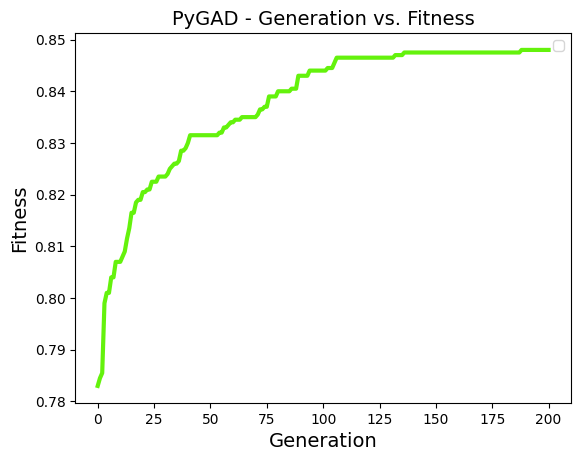

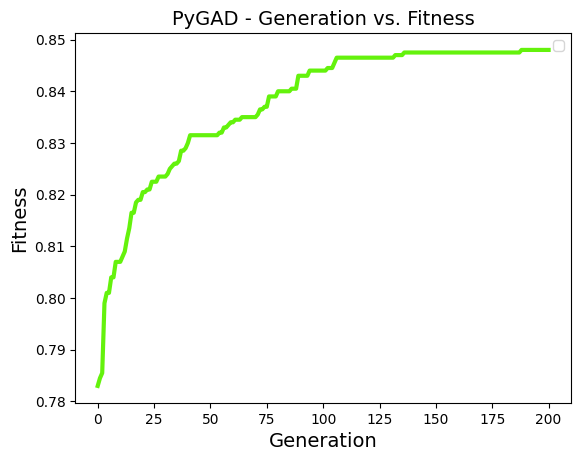

In [55]:
best_solution, best_fitness, _ = ga.best_solution()

# Evaluate on training set
fitness_train_after = evaluate_fitness(best_solution, X_train, y_train, n_features)

# Evaluate on test set (full data)
fitness_test_after = evaluate_fitness(best_solution, X_test, y_test, n_features)

print(f"Training Set Performance:")
print(f"  BEFORE GA: {fitness_train_before * 100:.2f}%")
print(f"  AFTER  GA: {fitness_train_after * 100:.2f}%")
print(f"  Improvement: {(fitness_train_after - fitness_train_before) * 100:.2f}%")

print(f"\nTest Set Performance:")
print(f"  BEFORE GA: {fitness_test_before * 100:.2f}%")
print(f"  AFTER GA: {fitness_test_after * 100:.2f}%")

ga.plot_fitness()